### **🧪 Model Exploration**

To detect duplicate questions in the dataset, the following approaches will be investigated:

- **Baseline models based on handcrafted features**  
Using the engineered features (shared words, Jaccard similarity, n-grams, Levenshtein distance, etc.) to evaluate their predictive power without complex text vectorization.

- **TF-IDF-based models**  
Transforming questions into numerical vectors based on term frequency and importance, allowing the model to capture the relevance of words in the text.

- **Semantic embeddings (SBERT)**  
Using pre-trained transformer models to capture deeper semantic similarity between questions.

- **Combined models**  
Combining handcrafted features with TF-IDF or SBERT representations to improve performance by leveraging different sources of information.

- **Evaluation metric**  
The main evaluation metric is Cross-Entropy Loss (Log Loss), which measures the quality of probabilistic predictions for the two classes.

**Research Goal:**  
To determine which approaches and feature combinations provide the best ability to distinguish duplicate question pairs from non-duplicate ones.

### **Data Preprocessing and Preparing Data for Modeling**

In [6]:
import warnings  
warnings.filterwarnings("ignore")

In [7]:
import pandas as pd
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src import Functions as fy
train_fname = '../data/quora_question_pairs_train.csv.zip'
df_train = pd.read_csv(train_fname)
df_train = df_train.dropna()
display(df_train.head(5)), df_train.info()

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1


<class 'pandas.core.frame.DataFrame'>
Index: 323429 entries, 0 to 323431
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            323429 non-null  int64 
 1   qid1          323429 non-null  int64 
 2   qid2          323429 non-null  int64 
 3   question1     323429 non-null  object
 4   question2     323429 non-null  object
 5   is_duplicate  323429 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 17.3+ MB


(None, None)

In [8]:
df_train, vectorizer, tfidf_q1_train, tfidf_q2_train = fy.tfidf_features(df_train)

In [13]:
import joblib
from scipy.sparse import save_npz

df_train.to_csv("../data/features_train.csv.zip", index=False, compression="zip")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

save_npz("../data/tfidf_q1_train.npz", tfidf_q1_train)
save_npz("../data/tfidf_q2_train.npz", tfidf_q2_train)

In [10]:
test_fname = '../data/quora_question_pairs_test.csv.zip'
df_test = pd.read_csv(test_fname)
df_test = df_test.dropna()
display(df_test.head(5)), df_test.info()

,id,qid1,qid2,question1,question2,is_duplicate
0,305985,429434,429435,Why is beef banned in India and not pork as well?,Is beef banned in india?,0
1,5193,10230,10231,At what valuation did Homejoy raise money in D...,Should a wealthy founder self-fund his second ...,0
2,123326,199422,199423,How do we judge?,How do I judge my love?,0
3,368557,327674,498931,Are Adderall and meth the same?,Are concerta and meth test the same?,0
4,369226,499645,499646,If you had internet access to only one site fo...,Why is there .co.uk for British internet sites...,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80858 entries, 0 to 80857
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            80858 non-null  int64 
 1   qid1          80858 non-null  int64 
 2   qid2          80858 non-null  int64 
 3   question1     80858 non-null  object
 4   question2     80858 non-null  object
 5   is_duplicate  80858 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 3.7+ MB


(None, None)

In [11]:
df_test, vectorizer, tfidf_q1_test, tfidf_q2_test = fy.tfidf_features(df_test, vectorizer)

In [21]:
df_test.to_csv("../data/features_test.csv.zip", index=False, compression="zip")

save_npz("../data/tfidf_q1_test.npz", tfidf_q1_test)
save_npz("../data/tfidf_q2_test.npz", tfidf_q2_test)

### **Data Loading and Model Training Using Engineered Features**


In [103]:
import joblib
from scipy.sparse import load_npz
import pandas as pd

df_test = pd.read_csv("../data/features_test.csv.zip")
df_train = pd.read_csv("../data/features_train.csv.zip")

In [45]:
from sklearn.metrics import log_loss
def evaluate_model(y_train_pred, y_val_pred, y_train, y_val, model_name="model"):
    """
    Evaluates the model using Cross-Entropy Loss (Log Loss)
    """

    train_loss = log_loss(y_train, y_train_pred)
    val_loss = log_loss(y_val, y_val_pred)

    print(f"{model_name}")
    print(f"  Train Log Loss: {train_loss:.4f}")
    print(f"  Val   Log Loss: {val_loss:.4f}")

    return {
        "model": model_name,
        "train_log_loss": train_loss,
        "val_log_loss": val_loss
    }

In [16]:
df_train.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_tokens,q2_tokens,q1_clean,q2_clean,common_words,jaccard,lev_ratio,bigram_overlap,trigram_overlap,cosine_sim,manhattan,euclidean
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,"['iliad', 'odyssey', 'greek', 'culture']","['prove', 'pair', 'three', 'independent', 'var...",iliad odyssey greek culture,prove pair three independent variable also ind...,0,0.000000,0.343750,0.000000,0.0,0.000000,4.252155,1.414214
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,"['practical', 'management', 'strategic', 'mana...","['practical', 'aspect', 'strategic', 'manageme...",practical management strategic management,practical aspect strategic management,3,0.750000,0.717949,0.200000,0.0,0.830298,0.924018,0.582584
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,"['useful', 'makeuseof', 'answer']","['q', 'site', 'yahoo', 'answer', 'hate', 'spee...",useful makeuseof answer,q site yahoo answer hate speech allow,1,0.111111,0.290909,0.000000,0.0,0.117978,3.384658,1.328173
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,"['best', 'place', 'reside', 'india']","['ia', 'best', 'place', 'visit', 'india']",best place reside india,ia best place visit india,3,0.500000,0.817204,0.166667,0.0,0.386806,1.903005,1.107424
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,"['many', 'people', 'ask', 'question', 'quora',...","['many', 'people', 'post', 'question', 'quora'...",many people ask question quora easily answer n...,many people post question quora check google f...,5,0.294118,0.466960,0.111111,0.0,0.329115,4.368383,1.158348


In [104]:
train_cols = ["common_words",	"jaccard", "lev_ratio",	"bigram_overlap",	"trigram_overlap",	"cosine_sim",	"manhattan", "euclidean"]
X_train = df_train[train_cols].copy()
X_test = df_test[train_cols].copy()
y_train = df_train["is_duplicate"].copy()
y_test = df_test["is_duplicate"].copy()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from lightgbm import LGBMClassifier

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba_test = model.predict_proba(X_test)
    y_proba_train = model.predict_proba(X_train)

    evaluate_model(y_proba_train[:, 1], y_proba_test[:, 1], y_train, y_test, model_name=name)

Logistic Regression
  Train Log Loss: 0.5639
  Val   Log Loss: 0.5663
Random Forest
  Train Log Loss: 0.1569
  Val   Log Loss: 0.5527
XGBoost
  Train Log Loss: 0.4869
  Val   Log Loss: 0.4956
LightGBM
  Train Log Loss: 0.4825
  Val   Log Loss: 0.4939


The baseline experiments with handcrafted features show that Random Forest suffers from overfitting, achieving a very low training Log Loss but significantly worse validation performance. Logistic Regression provides a simple baseline but shows signs of underfitting. In contrast, XGBoost and LightGBM demonstrate more stable results, achieving validation Log Loss values around 0.49–0.50. These results suggest that gradient boosting methods are better suited for this task among the evaluated classical models.

The next stage focuses on training models using vectorized question representations (TF-IDF and embeddings) to assess the impact of richer text features on classification performance.

### **Training Models on TF-IDF Matrices**

In [23]:
from scipy.sparse import hstack

tfidf_q1_train = load_npz("../data/tfidf_q1_train.npz")
tfidf_q2_train = load_npz("../data/tfidf_q2_train.npz")
tfidf_q1_test = load_npz("../data/tfidf_q1_test.npz")
tfidf_q2_test = load_npz("../data/tfidf_q2_test.npz")
X_tfidf_train = hstack([tfidf_q1_train, tfidf_q2_train])
X_tfidf_test = hstack([tfidf_q1_test, tfidf_q2_test])

In [24]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

lr = LogisticRegression(max_iter=1000)
lr.fit(X_tfidf_train, y_train)

svm = LinearSVC(max_iter=1000)
svm_clf = CalibratedClassifierCV(svm)
svm_clf.fit(X_tfidf_train, y_train)

sgd = SGDClassifier(loss='log_loss', max_iter=1000)
sgd.fit(X_tfidf_train, y_train)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if

In [25]:
for model, name in [(lr, "Logistic Regression"), (svm_clf, "Linear SVM"), (sgd, "SGD")]:
    y_proba_test = model.predict_proba(X_tfidf_test)
    y_proba_train = model.predict_proba(X_tfidf_train)

    evaluate_model(y_proba_train[:, 1], y_proba_test[:, 1], y_train, y_test, model_name=name)

Logistic Regression
  Train Log Loss: 0.4757
  Val   Log Loss: 0.5245
Linear SVM
  Train Log Loss: 0.4494
  Val   Log Loss: 0.5284
SGD
  Train Log Loss: 0.5480
  Val   Log Loss: 0.5542


At this stage, models trained on TF-IDF representations demonstrate slightly better performance compared to baseline models based on handcrafted features. Logistic Regression achieves the lowest validation Log Loss, followed by SVM, while SGD shows the weakest performance among the evaluated models.

The next step is to combine TF-IDF representations with engineered features and evaluate whether integrating different sources of information improves classification performance.

### **Training Models Using Engineered Features and TF-IDF**

In [26]:
import pandas as pd
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler

X_train_stack = hstack([X_tfidf_train, X_train.values])
X_test_stack = hstack([X_tfidf_test, X_test.values])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='saga'),
    "Linear SVM": LinearSVC(max_iter=2000),
    "LightGBM": LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_stack, y_train)
    if hasattr(model, "decision_function"):
        from scipy.special import expit
        y_proba_test = expit(model.decision_function(X_test_stack))
        y_proba_train = expit(model.decision_function(X_train_stack))
        evaluate_model(y_proba_train, y_proba_test, y_train, y_test, model_name=name)
    else:
        y_proba_test = model.predict_proba(X_test_stack)
        y_proba_train = model.predict_proba(X_train_stack)
        evaluate_model(y_proba_train[:, 1], y_proba_test[:, 1], y_train, y_test, model_name=name)


Training Logistic Regression...
Logistic Regression
  Train Log Loss: 0.3888
  Val   Log Loss: 0.4327
Training Linear SVM...
Linear SVM
  Train Log Loss: 0.4647
  Val   Log Loss: 0.5037
Training LightGBM...
LightGBM
  Train Log Loss: 0.3956
  Val   Log Loss: 0.4102


At this stage, a hybrid approach was applied by combining TF-IDF representations with handcrafted features. Logistic Regression and LightGBM demonstrate strong validation results, while SVM shows slightly lower performance.

The next step focuses on exploring semantic embeddings, such as SBERT, to evaluate whether deeper text representations can further improve classification performance.

In [105]:
import joblib
from scipy.sparse import load_npz
import pandas as pd


df_test = pd.read_csv("../data/features_test.csv.zip")
df_train = pd.read_csv("../data/features_train.csv.zip")

In [111]:
train_cols = ["common_words",	"jaccard", "lev_ratio",	"bigram_overlap",	"trigram_overlap",	"cosine_sim",	"manhattan", "euclidean", "sbert_cosine"]
X_train_emb = df_train[train_cols].copy()
X_test_emb = df_test[train_cols].copy()
y_train = df_train["is_duplicate"].copy()
y_test = df_test["is_duplicate"].copy()

In [30]:

X_train_stack = hstack([X_tfidf_train, X_train_emb.values])
X_test_stack = hstack([X_tfidf_test, X_test_emb.values])

LightGBM_model = LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
LightGBM_model.fit(X_train_stack, y_train)
y_proba_test = LightGBM_model.predict_proba(X_test_stack)
y_proba_train = LightGBM_model.predict_proba(X_train_stack)
evaluate_model(y_proba_train[:, 1], y_proba_test[:, 1], y_train, y_test, model_name="LightGBM_emb")

LightGBM_emb
  Train Log Loss: 0.2960
  Val   Log Loss: 0.3088


{'model': 'LightGBM_emb',
 'train_log_loss': 0.2960275923566571,
 'val_log_loss': 0.30875030832162137}

Adding cosine similarity between SBERT embeddings as an additional numerical feature significantly improved the model performance. The gradient boosting model effectively leveraged this semantic signal together with handcrafted features, achieving the lowest Log Loss among all evaluated approaches.

### SBERT

In this project, SBERT is used without fine-tuning because the dataset contains general-purpose questions rather than domain-specific text. The pre-trained model is already capable of capturing semantic relationships between questions and provides strong results without additional training.

Additionally, fine-tuning transformer models requires substantial computational resources and careful hyperparameter optimization, while the expected performance improvement for this task may be limited. Therefore, fixed SBERT embeddings were selected as a more practical and efficient approach.

In [34]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [107]:
df_test = pd.read_csv("../data/features_test.csv.zip")
df_train = pd.read_csv("../data/features_train.csv.zip")

In [41]:
df_train["q1_raw"] = df_train["question1"].astype(str)
df_train["q2_raw"] = df_train["question2"].astype(str)
df_test["q1_raw"] = df_test["question1"].astype(str)
df_test["q2_raw"] = df_test["question2"].astype(str)

In [42]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7621.57it/s]


In [43]:
emb_q1_train = model.encode(
    df_train["q1_raw"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

emb_q2_train = model.encode(
    df_train["q2_raw"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

Batches: 100%|██████████| 5054/5054 [17:57<00:00,  4.69it/s]


In [44]:
emb_q1_test = model.encode(
    df_test["q1_raw"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

emb_q2_test = model.encode(
    df_test["q2_raw"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

Batches: 100%|██████████| 1264/1264 [04:45<00:00,  4.43it/s]


In [ ]:
emb_q1_test = emb_q1_test.astype("float16")
emb_q2_test = emb_q2_test.astype("float16")
np.save("../data/emb_q1_fp16_test.npy", emb_q1_test)
np.save("../data/emb_q2_fp16_test.npy", emb_q2_test)

In [ ]:
emb_q1_train = emb_q1_train.astype("float16")
emb_q2_train = emb_q2_train.astype("float16")
np.save("../data/emb_q1_fp16_train.npy", emb_q1_train)
np.save("../data/emb_q2_fp16_train.npy", emb_q2_train)

In [71]:
emb_q1_train = np.load("../data/emb_q1_fp16_train.npy")
emb_q2_train = np.load("../data/emb_q2_fp16_train.npy")
emb_q1_test = np.load("../data/emb_q1_fp16_test.npy")
emb_q2_test = np.load("../data/emb_q2_fp16_test.npy")

In [108]:
from sklearn.metrics.pairwise import cosine_similarity

df_train["sbert_cosine"] = [
    cosine_similarity([e1], [e2])[0][0]
    for e1, e2 in zip(emb_q1_train, emb_q2_train)
]

df_test["sbert_cosine"] = [
    cosine_similarity([e1], [e2])[0][0]
    for e1, e2 in zip(emb_q1_test, emb_q2_test)
]

In [109]:
def l2_distance(a, b):
    return np.linalg.norm(a - b)

def dot_product(a, b):
    return np.dot(a, b)
df_train["sbert_l2"] = [
    l2_distance(e1, e2)
    for e1, e2 in zip(emb_q1_train, emb_q2_train)
]

df_train["sbert_dot"] = [
    dot_product(e1, e2)
    for e1, e2 in zip(emb_q1_train, emb_q2_train)
]

df_test["sbert_l2"] = [
    l2_distance(e1, e2)
    for e1, e2 in zip(emb_q1_test, emb_q2_test)
]

df_test["sbert_dot"] = [
    dot_product(e1, e2)
    for e1, e2 in zip(emb_q1_test, emb_q2_test)
]


In [110]:
df_train.to_csv("../data/features_emb_train.csv.zip", index=False, compression="zip")
df_test.to_csv("../data/features_emb_test.csv.zip", index=False, compression="zip")

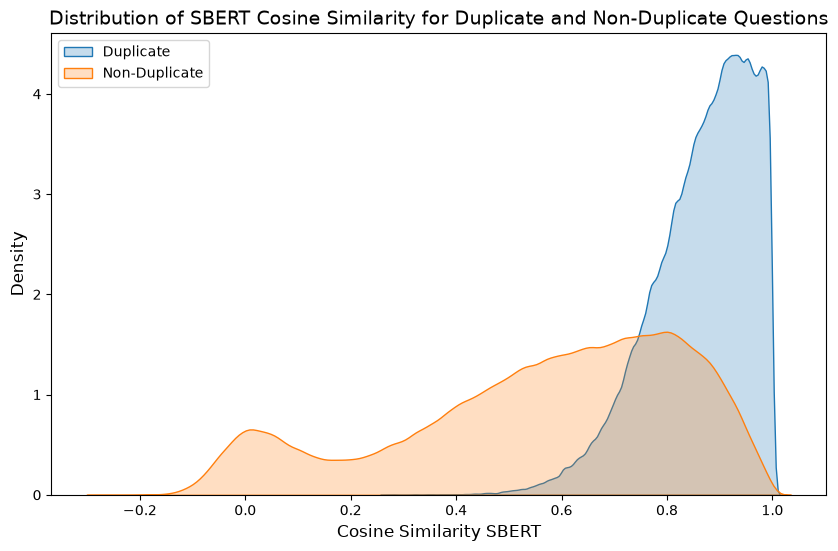

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

duplicates = df_train[df_train["is_duplicate"] == 1]["sbert_cosine"]
non_duplicates = df_train[df_train["is_duplicate"] == 0]["sbert_cosine"]

plt.figure(figsize=(10,6))

sns.kdeplot(duplicates, label="Duplicate", fill=True, bw_adjust=0.5)
sns.kdeplot(non_duplicates, label="Non-Duplicate", fill=True, bw_adjust=0.5)

plt.title("Distribution of SBERT Cosine Similarity for Duplicate and Non-Duplicate Questions", fontsize=14)
plt.xlabel("Cosine Similarity SBERT", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

X_train = df_train[["sbert_cosine"]]
X_test   = df_test[["sbert_cosine"]]

y_train = df_train["is_duplicate"]
y_test   = df_test["is_duplicate"]

model = LogisticRegression(max_iter=1000)
model.fit(X_test, y_test)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_val_proba   = model.predict_proba(X_test)[:, 1]

evaluate_model(y_train_proba, y_val_proba, y_train, y_test, "SBERT baseline")


SBERT baseline
  Train Log Loss: 0.4228
  Val   Log Loss: 0.4221


{'model': 'SBERT baseline',
 'train_log_loss': 0.42280395805427845,
 'val_log_loss': 0.42212287416910677}

In [55]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import log_loss
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from lightgbm.callback import early_stopping, log_evaluation

X_sbert_train = np.hstack([emb_q1_train, emb_q2_train, np.abs(emb_q1_train - emb_q2_train)])
X_sbert_test  = np.hstack([emb_q1_test, emb_q2_test, np.abs(emb_q1_test - emb_q2_test)])

y_train = df_train["is_duplicate"].values
y_test  = df_test["is_duplicate"].values

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(
    X_sbert_train, y_train,
    eval_set=[(X_sbert_test, y_test)],
    eval_metric="logloss",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50)
    ]
)

y_train_pred_lgbm = lgbm_model.predict_proba(X_sbert_train)[:,1]
y_test_pred_lgbm  = lgbm_model.predict_proba(X_sbert_test)[:,1]
evaluate_model(y_train_pred_lgbm, y_test_pred_lgbm, y_train, y_test, "LightGBM SBERT")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.434253
[100]	valid_0's binary_logloss: 0.385501
[150]	valid_0's binary_logloss: 0.363201
[200]	valid_0's binary_logloss: 0.35036
[250]	valid_0's binary_logloss: 0.341924
[300]	valid_0's binary_logloss: 0.335795
[350]	valid_0's binary_logloss: 0.331014
[400]	valid_0's binary_logloss: 0.327275
[450]	valid_0's binary_logloss: 0.324146
[500]	valid_0's binary_logloss: 0.321714
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.321714
LightGBM SBERT
  Train Log Loss: 0.2879
  Val   Log Loss: 0.3217


{'model': 'LightGBM SBERT',
 'train_log_loss': 0.2878961904213733,
 'val_log_loss': 0.321713932145651}

In [85]:
X_sbert_train = np.hstack([emb_q1_train, emb_q2_train, np.abs(emb_q1_train - emb_q2_train)])
X_sbert_test  = np.hstack([emb_q1_test, emb_q2_test, np.abs(emb_q1_test - emb_q2_test)])

In [ ]:
#Removed 3 near-zero variance SBERT features to prevent instability during scaling.
bad_cols = [319, 703, 1087]
X_sbert_train = np.delete(X_sbert_train, bad_cols, axis=1)
X_sbert_test = np.delete(X_sbert_test, bad_cols, axis=1)

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sbert_train_scaled = scaler.fit_transform(X_sbert_train)
X_sbert_test_scaled   = scaler.transform(X_sbert_test)

In [89]:

X_train_tensor = torch.tensor(X_sbert_train_scaled, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_sbert_test_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [97]:
from torch import nn

class SBERTMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.model(x)

mlp_model = SBERTMLP(X_sbert_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-4, weight_decay=1e-4)


n_epochs = 20
for epoch in range(n_epochs):
    mlp_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = mlp_model(xb).squeeze()
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

mlp_model.eval()
with torch.no_grad():
    y_train_pred_mlp = torch.sigmoid(
        mlp_model(X_train_tensor)
    ).cpu().numpy().squeeze()

    y_test_pred_mlp = torch.sigmoid(
        mlp_model(X_test_tensor)
    ).cpu().numpy().squeeze()

evaluate_model(y_train_pred_mlp, y_test_pred_mlp, y_train, y_test, "MLP SBERT")

Epoch 1/20, Loss: 0.3556
Epoch 2/20, Loss: 0.4450
Epoch 3/20, Loss: 0.3664
Epoch 4/20, Loss: 0.3417
Epoch 5/20, Loss: 0.2405
Epoch 6/20, Loss: 0.2426
Epoch 7/20, Loss: 0.2804
Epoch 8/20, Loss: 0.2430
Epoch 9/20, Loss: 0.3829
Epoch 10/20, Loss: 0.2676
Epoch 11/20, Loss: 0.2277
Epoch 12/20, Loss: 0.1828
Epoch 13/20, Loss: 0.1851
Epoch 14/20, Loss: 0.2411
Epoch 15/20, Loss: 0.1520
Epoch 16/20, Loss: 0.2172
Epoch 17/20, Loss: 0.1855
Epoch 18/20, Loss: 0.1345
Epoch 19/20, Loss: 0.1317
Epoch 20/20, Loss: 0.2137
MLP SBERT
  Train Log Loss: 0.1217
  Val   Log Loss: 0.3059


{'model': 'MLP SBERT',
 'train_log_loss': 0.12169822305440903,
 'val_log_loss': 0.3059248626232147}

In [ ]:
torch.save(mlp_model.state_dict(), "../models/sbert_mlp.pt")

In [ ]:
import joblib
joblib.dump(scaler, "../models/sbert_scaler.pkl")

['sbert_scaler.pkl']

The MLP model based on SBERT embeddings has been saved to ensure reproducibility of the results.

| Model | Features | Train Log Loss | Val Log Loss | Comment |
|------|----------|----------------|--------------|----------|
| Logistic Regression | Handcrafted features | 0.5639 | 0.5663 | Baseline model |
| Random Forest | Handcrafted features | 0.1569 | 0.5519 | Significant overfitting |
| XGBoost | Handcrafted features | 0.4868 | 0.4958 | Better than RF, without tuning |
| LightGBM | Handcrafted features | 0.4824 | 0.4938 | Best tabular model without TF-IDF |
| Logistic Regression | TF-IDF | 0.4766 | 0.5242 | Linear model on sparse text representations |
| Linear SVM | TF-IDF | 0.4494 | 0.5284 | Good training result, weaker validation performance |
| SGDClassifier | TF-IDF | 0.5480 | 0.5542 | Worst result |
| Logistic Regression | TF-IDF + handcrafted features | 0.3888 | 0.4327 | 🔥 Significant improvement |
| Linear SVM | TF-IDF + handcrafted features | 0.4648 | 0.5037 | No improvement compared to TF-IDF only |
| LightGBM | TF-IDF + handcrafted features | 0.3957 | 0.4102 | ⭐ Best classical model result |
| SBERT + Logistic Regression | SBERT Cosine Similarity | 0.4228 | 0.4221 | Strong result, embedding-based baseline |
| LightGBM SBERT | Sentence embeddings | 0.2879 | 0.3217 | 🔥 Significant improvement, promising approach |
| MLP + SBERT | Sentence embeddings | 0.1248 | 0.2822 | Shows signs of overfitting, but achieves strong validation performance |
| LightGBM | TF-IDF + handcrafted features + SBERT Cosine Similarity | 0.2962 | 0.3087 | ⭐ Best performing model |